<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Perceptron_Loss_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#The “perceptron trick” usually refers to the way a perceptron updates its decision boundary when it makes a mistake. It’s clever and simple—but it has some important limitations (problems).

🔧 What is the perceptron trick (quick recap)

A perceptron tries to classify data using a line (or hyperplane):

$\text{y = w \cdot x + b}$

When it misclassifies a point:

If the true label is +1, it moves the boundary toward the point
If the true label is −1, it moves the boundary away from the point

Update rule:

$\text{w = w + y_i x_i, b = b + y_i}$

❌ Problems with the Perceptron Trick
1. 🚫 Cannot handle non-linearly separable data

The biggest issue.

If data is not linearly separable, perceptron never converges
It keeps updating forever

📌 Example: XOR problem
Points cannot be separated by a straight line

2. 🔁 No guarantee of convergence (in real-world data)
Real datasets are noisy
Even slight overlap → infinite updates
Model keeps oscillating
3. ⚖️ Sensitive to outliers
One wrong or extreme point can keep shifting the boundary
No mechanism to “ignore” noisy data
4. 🧠 No probability output
Output is just +1 or -1
Unlike logistic regression, it doesn’t tell how confident it is
5. 📉 Only linear decision boundary
Can only learn straight lines / planes
Cannot learn curves or complex patterns
6. 🎯 Depends on learning order
Order of training data affects final weights
Different shuffling → different model

## The 'Loss Function' in a Perceptron (or lack thereof)

Unlike models such as Logistic Regression or Neural Networks, the traditional Perceptron does *not* use a continuously differentiable loss function (like Mean Squared Error or Cross-Entropy) that is optimized using gradient descent.

Instead, the Perceptron uses a much simpler, error-driven update rule. The 'loss' in a perceptron is implicitly handled by its mistake-driven learning approach:

### How the Perceptron Handles 'Loss':

1.  **No Continuous Loss Function**: The perceptron output is a hard classification (+1 or -1) based on whether the weighted sum of inputs exceeds a threshold. There's no probability or continuous value to compare against a true label using a standard loss function.

2.  **Mistake-Driven Learning**: The perceptron's learning algorithm is designed to correct misclassifications directly. It only updates its weights and bias when it makes a mistake on a training example.

    *   **If the perceptron correctly classifies an input**, no update occurs. The current weights and bias are considered 'good enough' for that specific point.

    *   **If the perceptron misclassifies an input**, an update is performed to move the decision boundary in the correct direction.

3.  **The Update Rule (as the 'Loss Correction')**:

    Let's say we have an input vector $\mathbf{x}_i$, a true label $y_i \in \{+1, -1\}$, and the perceptron's predicted output $\hat{y}_i$.

    The update rule for weights $\mathbf{w}$ and bias $b$ is:

    *   If $y_i = +1$ but $\hat{y}_i = -1$ (i.e., it predicted negative when it should have been positive):
        $\mathbf{w} \leftarrow \mathbf{w} + \eta \mathbf{x}_i$
        $b \leftarrow b + \eta$

    *   If $y_i = -1$ but $\hat{y}_i = +1$ (i.e., it predicted positive when it should have been negative):
        $\mathbf{w} \leftarrow \mathbf{w} - \eta \mathbf{x}_i$
        $b \leftarrow b - \eta$

    Where $\eta$ is the learning rate (often set to 1 in the basic perceptron algorithm).

    This can be compactly written as (assuming $\eta = 1$):

    $\mathbf{w} \leftarrow \mathbf{w} + y_i \mathbf{x}_i$
    $b \leftarrow b + y_i$

    **Intuition**: When a misclassification occurs, the update rule effectively pushes the decision boundary towards the correctly classified side of the misclassified point. For example, if a positive point is misclassified as negative, adding $y_i \mathbf{x}_i$ (which is $1 \cdot \mathbf{x}_i$) to the weights helps increase the dot product $\mathbf{w} \cdot \mathbf{x} + b$ for that point, making it more likely to be classified as positive next time.

### Conclusion:

In essence, the 'loss' in a perceptron is binary: either it's correct (no loss, no update) or it's incorrect (loss, trigger update). The update rule itself serves as the mechanism to reduce this 'loss' (i.e., reduce misclassifications) over iterations, aiming for convergence when the data is linearly separable.

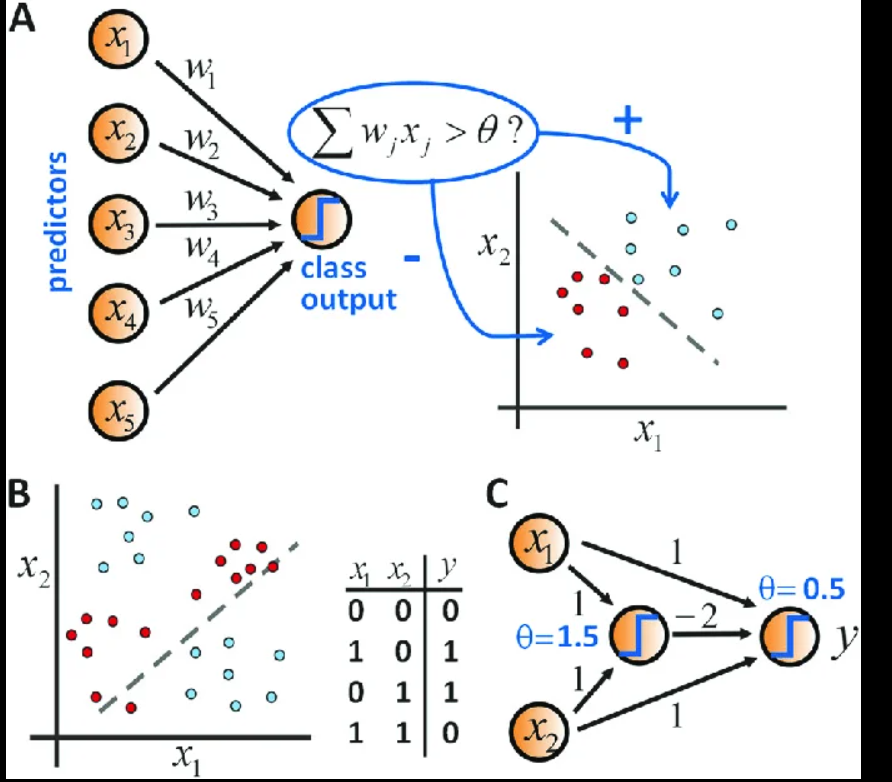

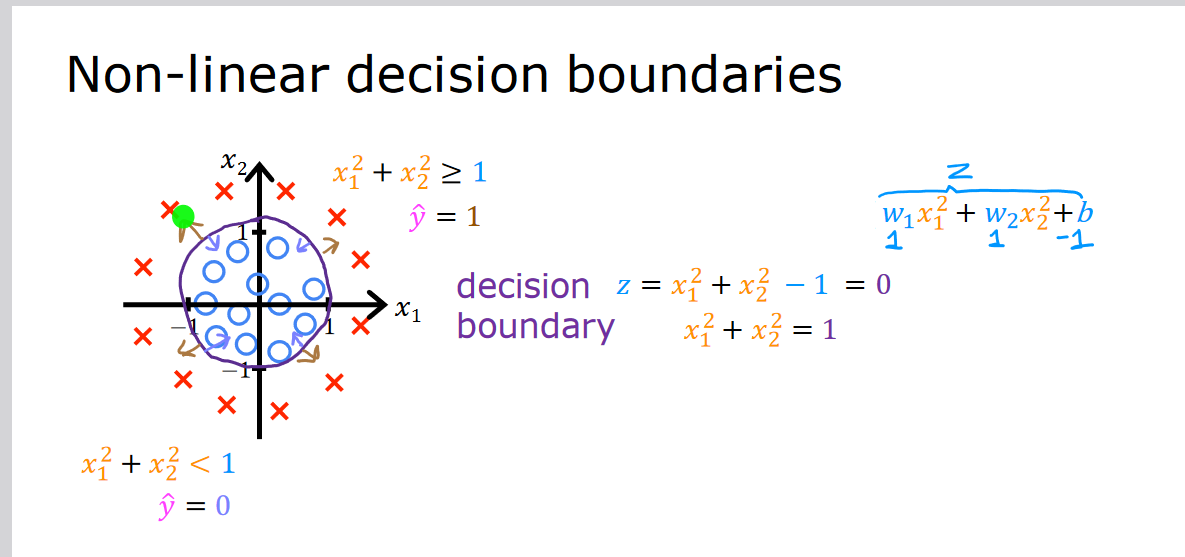

#📏 Distance from decision boundary

For a point $\mathbf{x}_i$, the signed distance is:

$d = \frac{\mathbf{w} \cdot \mathbf{x}_i + b}{\|\mathbf{w}\|}$

Positive → correct side
Negative → wrong side
Magnitude → how confident the prediction is
❌ Why basic perceptron does NOT use distance

Perceptron only checks:

$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \le 0$

👉 It ignores:

how far the point is
how confident the model is

So:

A slightly wrong point and a very wrong point are treated the same
✅ What happens if we use distance?

Then you get better models 👇

1. 🔥 SVM (Support Vector Machine)
Uses margin (distance) explicitly
Tries to maximize distance from boundary

Loss:

$\max(0, 1 - y_i (\mathbf{w} \cdot \mathbf{x}_i + b))$

👉 Penalizes even correct but close points

2. 📈 Logistic Regression
Uses distance as confidence (probability)
Far points → high confidence
Near boundary → uncertain
3. 🧠 Perceptron vs Improved Idea

| Feature           | Perceptron | Distance-based models |
|-------------------|------------|-----------------------|
| Uses distance?    | ❌ No      | ✅ Yes                |
| Handles uncertainty | ❌ No      | ✅ Yes                |
| Stability         | Low        | High                  |
| Real-world use    | Limited    | Very strong           |

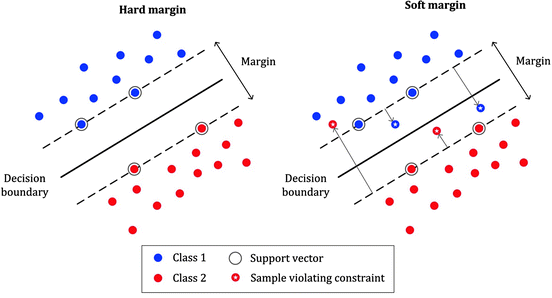

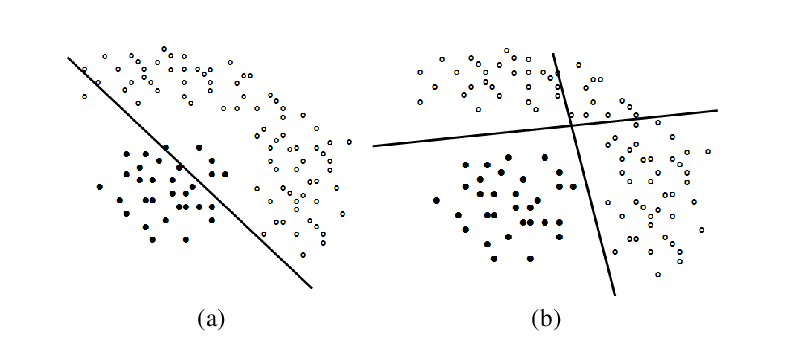

In [32]:

from sklearn.datasets import make_classification
import numpy as np
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_classes=2,n_clusters_per_class=1,n_redundant=0,random_state=41,hypercube=False,class_sep=10)



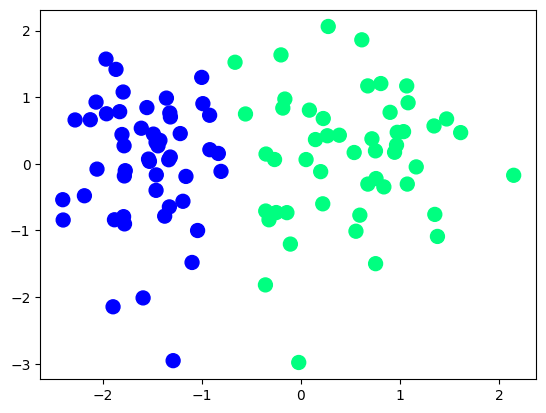

In [33]:

import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [34]:
 X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [35]:
X.shape


(100, 2)

In [36]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [37]:
y.shape

(100,)

#Function

In [38]:
def perceptron(X,y):
  w1=w2=b=1
  lr=0.1

  for j in range(1000):

     for i in range(X.shape[0]):

    #Check condition
        z=w1*X[i][0] +w2*X[i][1] +b

     if z*y[i] < 0:
          w1=w1 + lr * y[i]*X[i][0]
          w2=w2 + lr * y[i]*X[i][1]
          b=b + lr * y[i]

  return  w1,w2,b

### Perceptron Algorithm Explanation

This Python code defines a function `perceptron(X, y)` that implements a simple perceptron algorithm for binary classification. Here's a breakdown of what it does:

1.  **Initialization**: It starts by initializing `w1`, `w2` (weights for the two input features) and `b` (bias) to `1`. The `lr` (learning rate) is set to `0.1`.

2.  **Training Loop**: The algorithm iterates through the training data multiple times (1000 epochs, controlled by the outer `for j in range(1000)` loop). This allows the perceptron to learn from the data iteratively.

3.  **Data Point Iteration**: In each epoch, it goes through every data point (`X[i]`) and its corresponding label (`y[i]`) using the inner `for i in range(X.shape[0])` loop.

4.  **Prediction (`z`)**: For each data point `X[i]`, it calculates a weighted sum of the inputs plus the bias: `z = w1 * X[i][0] + w2 * X[i][1] + b`. This `z` value represents the perceptron's raw output.

5.  **Weight and Bias Update**: The core of the perceptron algorithm is the update rule. If `z * y[i] < 0`, it means the perceptron made a mistake in its classification:
    *   If `y[i]` is positive, but `z` is negative (wrong side).
    *   If `y[i]` is negative, but `z` is positive (wrong side).
    
    In case of a misclassification, the weights (`w1`, `w2`) and bias (`b`) are adjusted to move the decision boundary closer to correctly classifying the current data point. The `lr` (learning rate) controls the step size of these adjustments.

6.  **Return Values**: After all epochs, the function returns the final learned `w1`, `w2`, and `b` values, which define the decision boundary (`w1*x + w2*y + b = 0`).

In [39]:
def perceptron(X,y):
  w1=w2=b=1
  lr=0.1

  for j in range(1000):

     for i in range(X.shape[0]):

    #Check condition
        z=w1*X[i][0] +w2*X[i][1] +b

     if z*y[i] < 0:
          w1=w1 + lr * y[i]*X[i][0]
          w2=w2 + lr * y[i]*X[i][1]
          b=b + lr * y[i]

  return  w1,w2,b

In [40]:
w1,w2,b=perceptron(X,y)

In [41]:
m= -(w1/w2)
c= -(b/w2)

In [42]:
print(m,c)

-1.0 -1.0


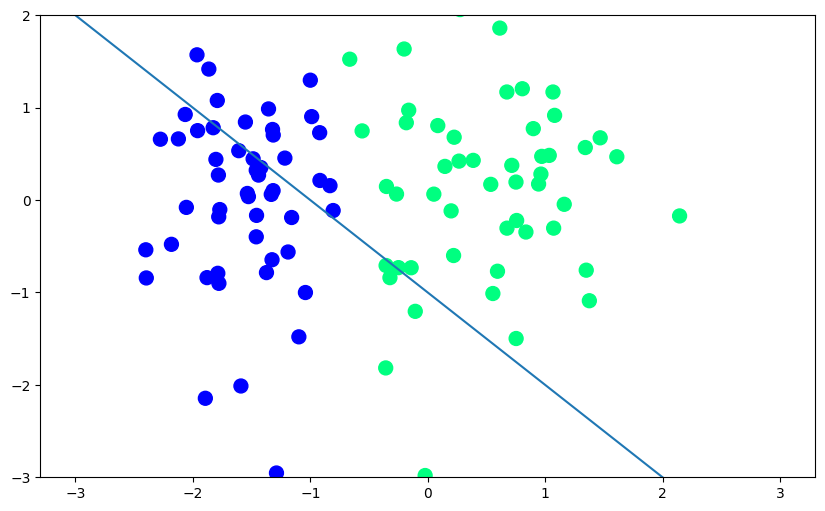

In [43]:
X_input=np.linspace(-3,3,100)
y_input=m * X_input + c
plt.figure(figsize=(10,6))
plt.plot(X_input,y_input)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()